In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow
from tensorflow import keras 
from keras import Sequential
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout, Input
from keras.applications.vgg16 import VGG16#Transfer learning  

In [3]:
# train,test se images perform.
df_train = keras.preprocessing.image_dataset_from_directory(
    directory = 'TRAIN',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(150, 150),
)
df_test = keras.preprocessing.image_dataset_from_directory(
    directory = 'TEST',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(150, 150),
)

Found 330 files belonging to 7 classes.
Found 78 files belonging to 7 classes.


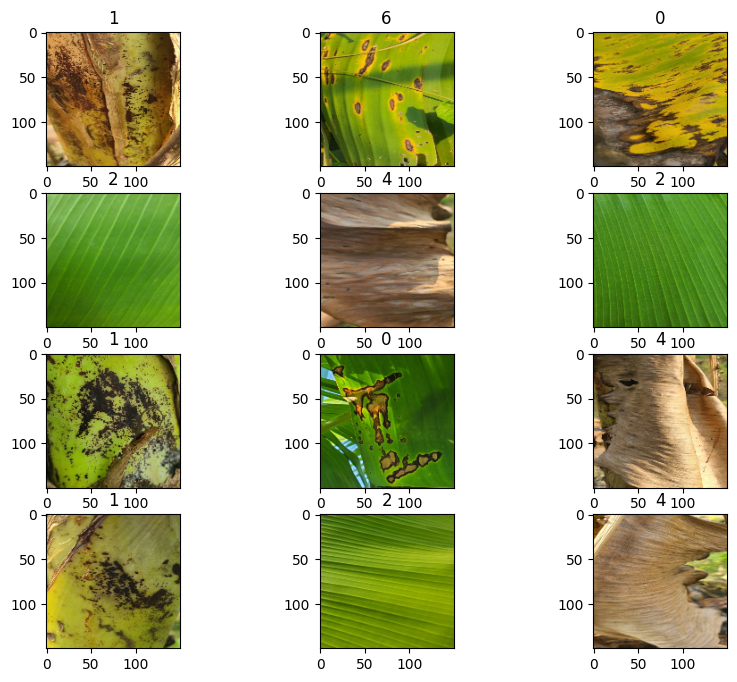

In [4]:
def plot_images(images, labels, num_images=12):
    plt.figure(figsize = [10, 8])
    for i in range(num_images):
        plt.subplot(4, 3, i+ 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(labels[i].numpy())
for images, labels in df_train.take(1):
    plot_images(images, labels)
    plt.show()

In [5]:
def process(image, label):
    image = tensorflow.cast(image/255, tensorflow.float32)#standarization te
    #3d dimensional array =tensor
    return image, label
df_train = df_train.map(process)
df_test = df_test.map(process)

In [7]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation = 'relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(Dense(64, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(7, activation = 'softmax'))
model.summary()

c:\Users\ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838,727 (18.46 MB)

 Trainable params: 4,837,895 (18.46 MB)

 Non-trainable params: 832 (3.25 KB)

In [8]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [9]:
history2 = model.fit(df_train, epochs=10, validation_data=df_test)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 329ms/step - accuracy: 0.4606 - loss: 1.6403 - val_accuracy: 0.1923 - val_loss: 1.8573
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - accuracy: 0.6364 - loss: 1.0300 - val_accuracy: 0.2051 - val_loss: 1.8782
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.6788 - loss: 0.8937 - val_accuracy: 0.2051 - val_loss: 1.8721
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.7697 - loss: 0.7121 - val_accuracy: 0.2179 - val_loss: 1.9696
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.8212 - loss: 0.6514 - val_accuracy: 0.2179 - val_loss: 2.1278
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 0.8121 - loss: 0.5753 - val_accuracy: 0.2179 - val_loss: 2.0320
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8242 - loss: 0.5077 - val_accuracy: 0.2179 - val_loss: 2.1515
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.8485 - loss: 0.4503 - val_accuracy: 0.21

In [10]:
#transfer learning

from tensorflow import keras

df_train = keras.preprocessing.image_dataset_from_directory(
    directory='TRAIN',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
)

df_test = keras.preprocessing.image_dataset_from_directory(
    directory='TEST',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
)


Found 330 files belonging to 7 classes.
Found 78 files belonging to 7 classes.


In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load pre-trained VGG16 without classifier head
base_model = VGG16(input_shape=(224, 224, 3),
                   include_top=False,
                   weights='imagenet')

# Freeze base model
base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [12]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')  # 7 classes, softmax for multi-class
])


In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [14]:
history = model.fit(
    df_train,
    validation_data=df_test,
    epochs=10
)


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 73s 7s/step - accuracy: 0.5333 - loss: 17.3032 - val_accuracy: 0.8077 - val_loss: 4.7516
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.8485 - loss: 6.0250 - val_accuracy: 0.8333 - val_loss: 2.1772
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9061 - loss: 2.4415 - val_accuracy: 0.8333 - val_loss: 3.8582
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9455 - loss: 1.7064 - val_accuracy: 0.8333 - val_loss: 2.8702
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9697 - loss: 0.9852 - val_accuracy: 0.8333 - val_loss: 4.8213
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9485 - loss: 0.9238 - val_accuracy: 0.8590 - val_loss: 2.7260
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9727 - loss: 0.4768 - val_accuracy: 0.8462 - val_loss: 2.2081
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9818 - loss: 0.3213 - val_accuracy: 0.8718 - val_loss

In [15]:
model.save('my_model.h5')


In [16]:
from tensorflow.keras.models import load_model
model = load_model('my_model.h5')


In [23]:
# Path to the image you want to predict
img_path = 'TRAIN\Banana Healthy Leaf\Healthy Leaf (3).jpg'

# Load the image and resize to (224, 224) as required by VGG16
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Expand dims to create a batch of size 1
img_batch = np.expand_dims(img_array, axis=0)

# Optional: normalize to 0–1 if your training data was scaled
img_batch = img_batch / 255.0


In [24]:
# Predict the class probabilities
predictions = model.predict(img_batch)

# Get the class with highest probability
predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


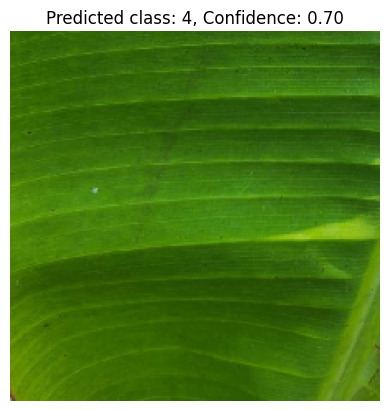

In [25]:
# Optional: show image
plt.imshow(img)
plt.axis('off')
plt.title(f'Predicted class: {predicted_class}, Confidence: {confidence:.2f}')
plt.show()
